# Small Test

**Table of contents**<a id='toc0_'></a>    
- 1. [Settings](#toc1_)    
- 2. [DP](#toc2_)    
- 3. [DL](#toc3_)    
- 4. [Reward](#toc4_)    
- 5. [Compare life-cycle profiles](#toc5_)    
  - 5.1. [States](#toc5_1_)    
  - 5.2. [Outcomes](#toc5_2_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({"axes.grid" : True, "grid.color": "black", "grid.alpha":"0.25", "grid.linestyle": "--"})
plt.rcParams.update({'font.size': 14})

In [4]:
from EconDLSolvers import choose_gpu

In [5]:
from DurablesModel import DurablesModelClass
from DurablesModelEGM import DurablesModelEGMClass

## 1. <a id='toc1_'></a>[Settings](#toc0_)

In [6]:
par = {'D':1,'full':False}
K_time = 1.0

In [7]:
from DurablesModel import get_omega_delta_d_ubar

for D in [1,2,3,8]:
    omega,delta,d_ubar = get_omega_delta_d_ubar(D,omega_base=0.2)
    print(f'{D = }',omega)

D = 1 tensor([0.2000], dtype=torch.float64)
D = 2 tensor([0.1291, 0.0709], dtype=torch.float64)
D = 3 tensor([0.1081, 0.0593, 0.0326], dtype=torch.float64)
D = 8 tensor([0.0910, 0.0499, 0.0274, 0.0150, 0.0083, 0.0045, 0.0025, 0.0014],
       dtype=torch.float64)


## 2. <a id='toc2_'></a>[DP](#toc0_)

In [8]:
model_dp = DurablesModelEGMClass(name='DP',par=par)
model_dp.link_to_cpp(force_compile=False)
model_dp.solve()
model_dp.simulate_R()
print(f'R = {model_dp.sim.R:12.8f}')

R =  -6.91068326


In [9]:
model_dp_pure_vfi = model_dp.copy()
model_dp_pure_vfi.egm.pure_vfi = True
model_dp_pure_vfi.solve()
model_dp_pure_vfi.simulate_R()
print(f'R = {model_dp_pure_vfi.sim.R:12.8f}')

R =  -6.91081119


## 3. <a id='toc3_'></a>[DL](#toc0_)

In [10]:
algonames = ['DeepSimulate','DeepFOC','DeepVPD','DeepVPD-FOC']

In [11]:
device = choose_gpu()

No GPU available, using CPU


In [12]:
models_dl = {}

In [13]:
for algoname in algonames:

    print(f'{algoname}')

    train = {'K_time':K_time}
    train['use_FOC'] = False
    if algoname in ['DeepVPD-FOC']:
        algoname_ = 'DeepVPD'
        train['use_FOC'] = True
        train['NFOC_targets'] = 2
    else:
        algoname_ = algoname

    KKT = algoname == 'DeepFOC' or train['use_FOC']
    model_dl = DurablesModelClass(algoname=algoname_,device=device,par={**par,'KKT':KKT},train=train)
    model_dl.solve(do_print=True)

    models_dl[algoname] = model_dl

    print('')

DeepSimulate


started solving: 2026-01-29 15:32:40


k =     0 of inf: sim.R =    -8.22603416 [best:    -8.22603416] [0.2 secs] [value_epochs =   0] [policy_epochs =   1] [  0.00 mins] [policy_lr = 1.0e-03]


k =    50 of inf: sim.R =    -7.14631081 [best:    -7.14631081] [0.3 secs] [value_epochs =   0] [policy_epochs =   1] [  0.07 mins] [policy_lr = 1.0e-03]


k =   100 of inf: sim.R =    -6.98865366 [best:    -6.98865366] [0.2 secs] [value_epochs =   0] [policy_epochs =   1] [  0.13 mins] [policy_lr = 1.0e-03]


...

k =    20 of inf: sim.R =    -6.95694304 [best:    -6.95694304] [1.3 secs] [value_epochs = 150] [policy_epochs =  15] [  0.35 mins] [policy_lr = 9.9e-04] [value_lr = 9.8e-04]


k =    30 of inf: sim.R =    -6.92172384 [best:    -6.92172384] [1.3 secs] [value_epochs = 150] [policy_epochs =  15] [  0.55 mins] [policy_lr = 9.8e-04] [value_lr = 9.7e-04]


k =    40 of inf: sim.R =    -6.91727066 [best:    -6.91727066] [1.3 secs] [value_epochs = 150] [policy_epochs =  15] [  0.75 mins] [policy_lr = 9.7e-04] [value_lr = 9.6e-04]


k =    50 of inf: sim.R =    -6.91488695 [best:    -6.91488695] [1.3 secs] [value_epochs = 150] [policy_epochs =  15] [  0.95 mins] [policy_lr = 9.6e-04] [value_lr = 9.5e-04]


Terminating after 54 episodes, max time 1.0 mins reached
R = -6.9145, time = 1.0 mins, iter = 54, policy epochs = 12.22, value epochs = 148.41



In [14]:
for algoname in algonames:
    assert np.allclose(model_dp.sim.states[0],models_dl[algoname].sim.states[0].numpy())
    assert np.allclose(model_dp.sim.shocks,models_dl[algoname].sim.shocks.numpy())

## 4. <a id='toc4_'></a>[Reward](#toc0_)

In [15]:
print(f'DP             : {model_dp.sim.R : 8.4f}')
for algoname in algonames:
    if not algoname in models_dl: continue
    model_dl = models_dl[algoname]
    print(f'{algoname:15s}: {model_dl.sim.R : 8.4f}')

DP             :  -6.9107
DeepSimulate   :  -6.9126
DeepFOC        :  -6.9161
DeepVPD        :  -6.9881
DeepVPD-FOC    :  -6.9145


## 5. <a id='toc5_'></a>[Compare life-cycle profiles](#toc0_)

In [16]:
lss = ['--', '-.', ':']*2

### 5.1. <a id='toc5_1_'></a>[States](#toc0_)

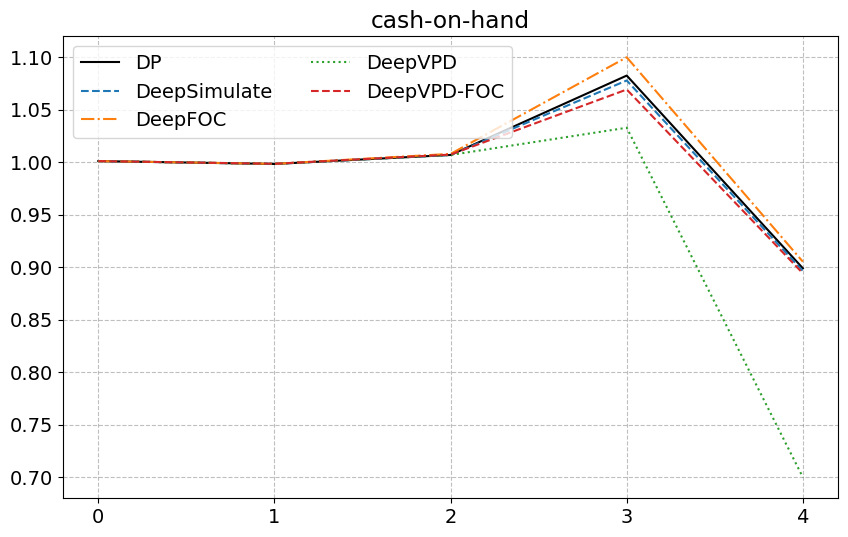

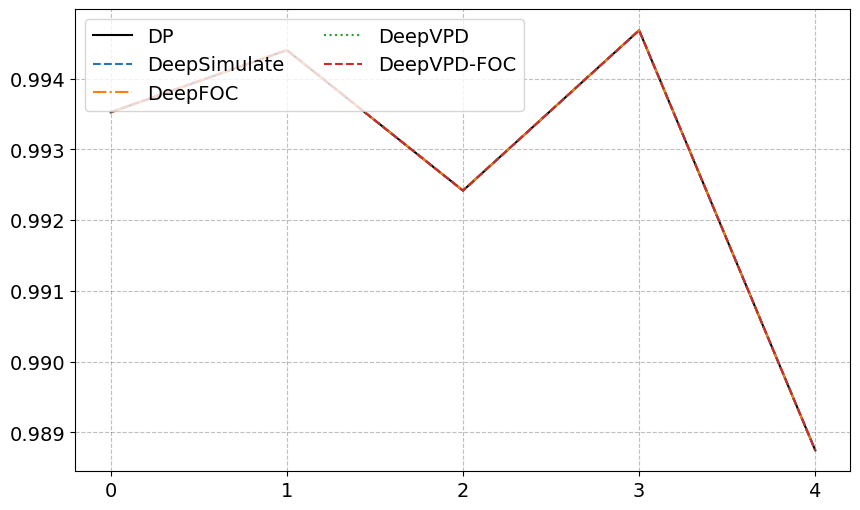

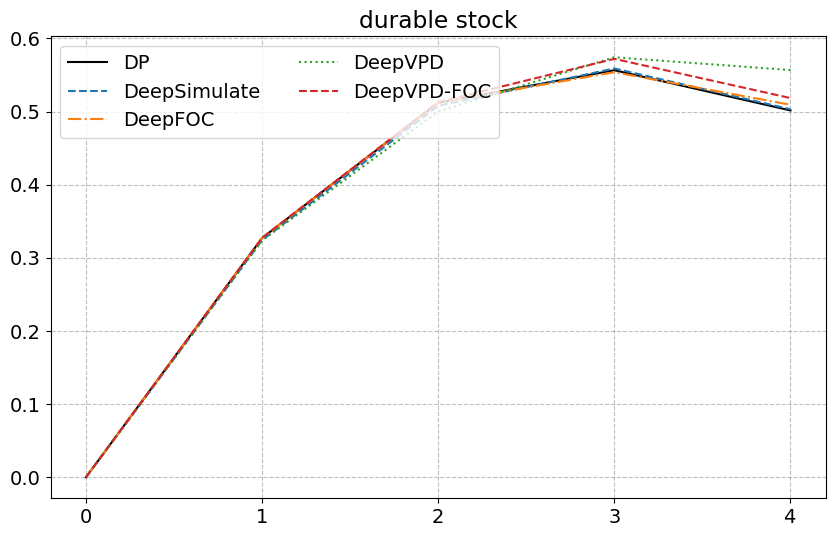

In [17]:
for j in range(3):

    fig,ax = plt.subplots(1,1,figsize=(10,6))

    ax.plot(model_dp.sim.states[:,:,j].mean(axis=1),label='DP',color='black')

    for i,algoname in enumerate(algonames):

        if not algoname in models_dl: continue    
        model_dl = models_dl[algoname]
        ax.plot(model_dl.sim.states[:,:,j].mean(axis=1),label=f'{algoname}',color=colors[i],ls=lss[i])

    if j == 0:
        ax.set_title(f'cash-on-hand')
    elif j == 2:
        ax.set_title(f'durable stock')
        
    ax.legend(ncol=2,loc='upper left')
    ax.set_xticks(np.arange(model_dp.par.T))

    plt.show()

### 5.2. <a id='toc5_2_'></a>[Outcomes](#toc0_)

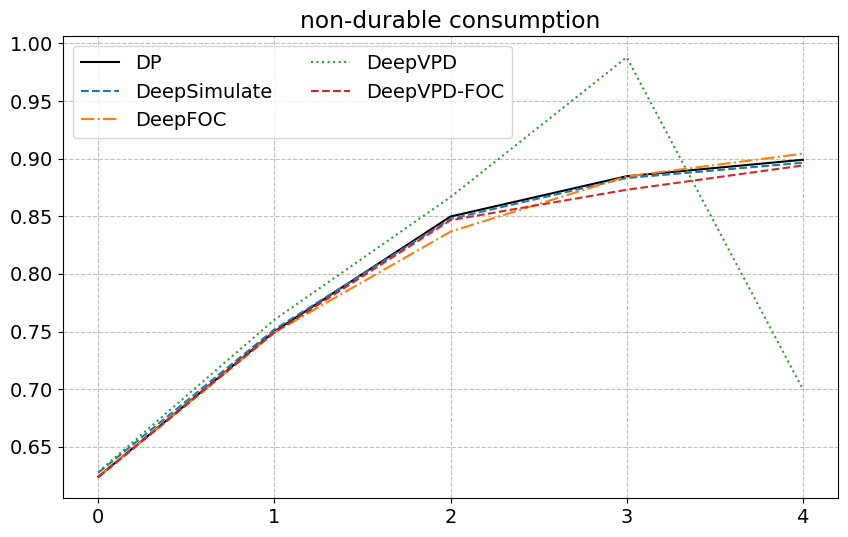

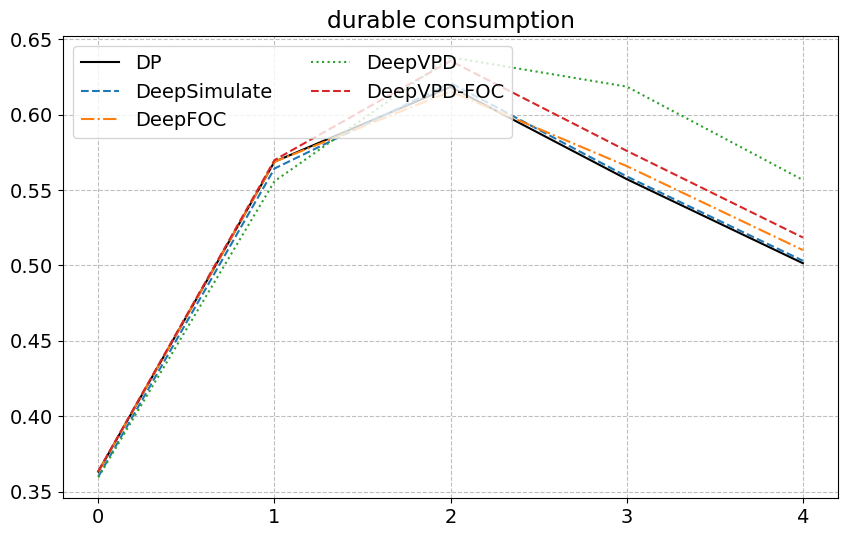

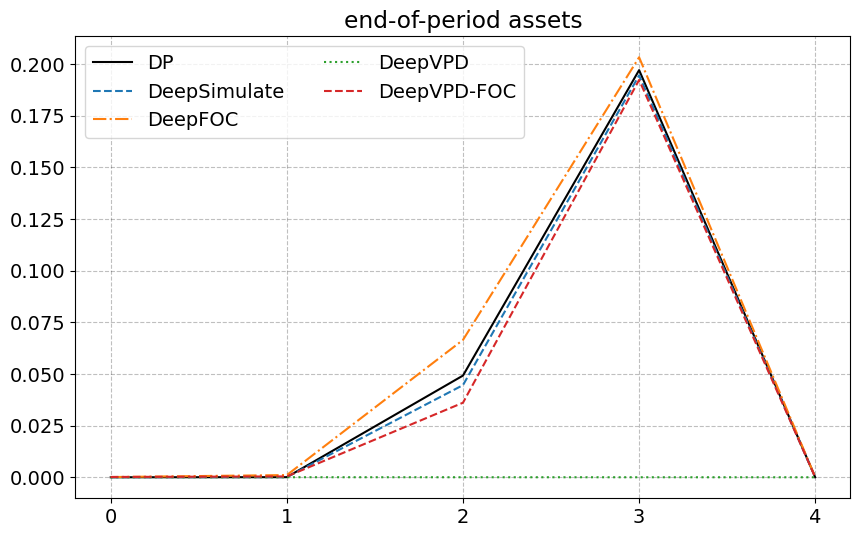

In [18]:
for j in range(3):

    fig,ax = plt.subplots(1,1,figsize=(10,6))

    ax.plot(model_dp.sim.outcomes[:,:,j].mean(axis=1),label='DP',color='black')

    for i,algoname in enumerate(algonames):

        if not algoname in models_dl: continue    
        model_dl = models_dl[algoname]
        ax.plot(model_dl.sim.outcomes[:,:,j].mean(axis=1),label=f'{algoname}',color=colors[i],ls=lss[i])

    if j == 0:
        ax.set_title(f'non-durable consumption')
    elif j == 1:
        ax.set_title(f'durable consumption')
    elif j == 2:
        ax.set_title(f'end-of-period assets')
        
    ax.legend(ncol=2,loc='upper left')
    ax.set_xticks(np.arange(model_dp.par.T))
    
    plt.show()